# Proyecto 2 - Detección de objetos con YOLO
## Detección de residuos reciclables

**Integrantes:**  Juan José Betancourt Osorio, Jean Pierre Henriquez Ebrat, Guillermo Alexander Zabala Fernandez
**Curso:** Visión Computacional con Deep Learning  
**Modelo base:** YOLO11s  
**Dataset:** residuos_dataset

### Objetivo
Entrenar un modelo YOLO con transferencia de aprendizaje para detectar tipos de residuos en imágenes y evaluar su desempeño en datos no vistos.


In [1]:
%pip install -q ultralytics opencv-python matplotlib pyyaml pandas pillow

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
from ultralytics import YOLO
from pathlib import Path
import yaml
import torch
import cv2
import matplotlib.pyplot as plt
from PIL import Image
import pandas as pd
import random
import os


In [2]:
NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent
DATASET_DIR = PROJECT_ROOT / "data" / "residuos_dataset"
DATA_YAML = DATASET_DIR / "data.yaml"
RUNS_DIR = PROJECT_ROOT / "runs"
MODELS_DIR = PROJECT_ROOT / "models"



print("NOTEBOOK_DIR:", NOTEBOOK_DIR)
print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATASET_DIR:", DATASET_DIR)
print("DATA_YAML:", DATA_YAML)
print("MODELS_DIR:", MODELS_DIR)
print("Existe data.yaml:", DATA_YAML.exists())
print("CUDA disponible:", torch.cuda.is_available())


NOTEBOOK_DIR: c:\Users\jujob\OneDrive\Escritorio\Maestria\Segundo_Semestre\Vision Computacional\Proyecto_2\repo\proyecto_yolo_residuos\notebooks
PROJECT_ROOT: c:\Users\jujob\OneDrive\Escritorio\Maestria\Segundo_Semestre\Vision Computacional\Proyecto_2\repo\proyecto_yolo_residuos
DATASET_DIR: c:\Users\jujob\OneDrive\Escritorio\Maestria\Segundo_Semestre\Vision Computacional\Proyecto_2\repo\proyecto_yolo_residuos\data\residuos_dataset
DATA_YAML: c:\Users\jujob\OneDrive\Escritorio\Maestria\Segundo_Semestre\Vision Computacional\Proyecto_2\repo\proyecto_yolo_residuos\data\residuos_dataset\data.yaml
MODELS_DIR: c:\Users\jujob\OneDrive\Escritorio\Maestria\Segundo_Semestre\Vision Computacional\Proyecto_2\repo\proyecto_yolo_residuos\models
Existe data.yaml: True
CUDA disponible: True


In [3]:
with open(DATA_YAML, "r", encoding="utf-8") as f:
    data_cfg = yaml.safe_load(f)

data_cfg


{'path': 'C:/Users/jujob/OneDrive/Escritorio/Maestria/Segundo_Semestre/Vision Computacional/Proyecto_2/repo/proyecto_yolo_residuos/data/residuos_dataset',
 'train': 'train/images',
 'val': 'valid/images',
 'test': 'test/images',
 'nc': 7,
 'names': {0: 'Electronics',
  1: 'Glass',
  2: 'Metal',
  3: 'Miscellaneous',
  4: 'Organic',
  5: 'Paper',
  6: 'Plastic'}}

In [4]:
required_paths = [
    DATASET_DIR / "train" / "images",
    DATASET_DIR / "train" / "labels",
    DATASET_DIR / "valid" / "images",
    DATASET_DIR / "valid" / "labels",
    DATASET_DIR / "test" / "images",
    DATASET_DIR / "test" / "labels",
]

for p in required_paths:
    print(p, "->", p.exists())


c:\Users\jujob\OneDrive\Escritorio\Maestria\Segundo_Semestre\Vision Computacional\Proyecto_2\repo\proyecto_yolo_residuos\data\residuos_dataset\train\images -> True
c:\Users\jujob\OneDrive\Escritorio\Maestria\Segundo_Semestre\Vision Computacional\Proyecto_2\repo\proyecto_yolo_residuos\data\residuos_dataset\train\labels -> True
c:\Users\jujob\OneDrive\Escritorio\Maestria\Segundo_Semestre\Vision Computacional\Proyecto_2\repo\proyecto_yolo_residuos\data\residuos_dataset\valid\images -> True
c:\Users\jujob\OneDrive\Escritorio\Maestria\Segundo_Semestre\Vision Computacional\Proyecto_2\repo\proyecto_yolo_residuos\data\residuos_dataset\valid\labels -> True
c:\Users\jujob\OneDrive\Escritorio\Maestria\Segundo_Semestre\Vision Computacional\Proyecto_2\repo\proyecto_yolo_residuos\data\residuos_dataset\test\images -> True
c:\Users\jujob\OneDrive\Escritorio\Maestria\Segundo_Semestre\Vision Computacional\Proyecto_2\repo\proyecto_yolo_residuos\data\residuos_dataset\test\labels -> True


In [5]:
def count_images(folder):
    exts = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
    return len([f for f in folder.iterdir() if f.suffix.lower() in exts])

train_count = count_images(DATASET_DIR / "train" / "images")
valid_count = count_images(DATASET_DIR / "valid" / "images")
test_count = count_images(DATASET_DIR / "test" / "images")

print("Train:", train_count)
print("Valid:", valid_count)
print("Test:", test_count)
print("Total:", train_count + valid_count + test_count)


Train: 9116
Valid: 2302
Test: 1248
Total: 12666


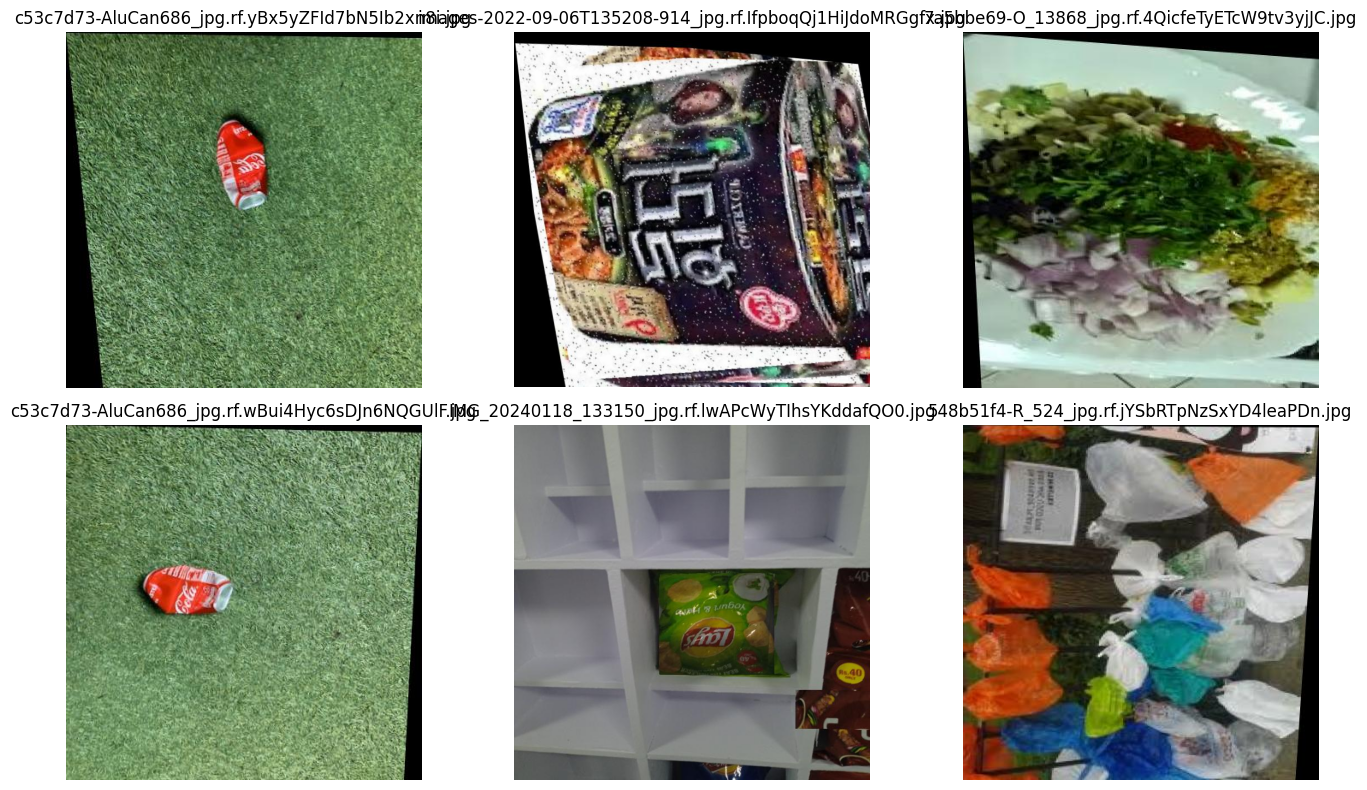

In [6]:
train_images_dir = DATASET_DIR / "train" / "images"
image_files = list(train_images_dir.glob("*.*"))
sample_files = random.sample(image_files, min(6, len(image_files)))

plt.figure(figsize=(14, 8))
for i, img_path in enumerate(sample_files, 1):
    img = Image.open(img_path)
    plt.subplot(2, 3, i)
    plt.imshow(img)
    plt.title(img_path.name)
    plt.axis("off")
plt.tight_layout()
plt.show()


In [8]:
model = YOLO("yolo11s.pt")
model.info()


YOLO11s summary: 181 layers, 9,458,752 parameters, 0 gradients, 21.7 GFLOPs


(181, 9458752, 0, 21.718374400000002)

In [9]:
model = YOLO("yolo11s.pt")

results = model.train(
    data=str(DATA_YAML),
    epochs=30,
    imgsz=640,
    batch=8,
    pretrained=True,
    project=str(RUNS_DIR),
    name="residuos_yolo11s",
    val=True,
    plots=True,
    patience=15,
    device=0 if torch.cuda.is_available() else "cpu"
)


Ultralytics 8.4.27  Python-3.14.0 torch-2.11.0+cu126 CUDA:0 (NVIDIA GeForce RTX 3060 Laptop GPU, 6144MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=c:\Users\jujob\OneDrive\Escritorio\Maestria\Segundo_Semestre\Vision Computacional\Proyecto_2\repo\proyecto_yolo_residuos\data\residuos_dataset\data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s.pt, momentum=0.937, mosaic

In [8]:
best_model_path = RUNS_DIR / "residuos_yolo11s3" / "weights" / "best.pt"
last_model_path = RUNS_DIR / "residuos_yolo11s3" / "weights" / "last.pt"

print("best.pt:", best_model_path, best_model_path.exists())
print("last.pt:", last_model_path, last_model_path.exists())


best.pt: c:\Users\jujob\OneDrive\Escritorio\Maestria\Segundo_Semestre\Vision Computacional\Proyecto_2\repo\proyecto_yolo_residuos\runs\residuos_yolo11s3\weights\best.pt True
last.pt: c:\Users\jujob\OneDrive\Escritorio\Maestria\Segundo_Semestre\Vision Computacional\Proyecto_2\repo\proyecto_yolo_residuos\runs\residuos_yolo11s3\weights\last.pt True


In [9]:
import shutil

final_model_path = MODELS_DIR / "best_residuos_yolo11s3.pt"

if best_model_path.exists():
    shutil.copy2(best_model_path, final_model_path)
    print("Modelo copiado a:", final_model_path)
else:
    print("No se encontró best.pt")


Modelo copiado a: c:\Users\jujob\OneDrive\Escritorio\Maestria\Segundo_Semestre\Vision Computacional\Proyecto_2\repo\proyecto_yolo_residuos\models\best_residuos_yolo11s3.pt


In [10]:
best_model = YOLO(str(final_model_path))
best_model.info()


YOLO11s summary: 182 layers, 9,430,501 parameters, 0 gradients, 21.6 GFLOPs


(182, 9430501, 0, 21.5613952)

In [11]:
metrics = best_model.val(data=str(DATA_YAML))
metrics


Ultralytics 8.4.27  Python-3.14.0 torch-2.11.0+cu126 CUDA:0 (NVIDIA GeForce RTX 3060 Laptop GPU, 6144MiB)
YOLO11s summary (fused): 101 layers, 9,415,509 parameters, 0 gradients, 21.3 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 107.560.8 MB/s, size: 39.6 KB)
val: Scanning C:\Users\jujob\OneDrive\Escritorio\Maestria\Segundo_Semestre\Vision Computacional\Proyecto_2\repo\proyecto_yolo_residuos\data\residuos_dataset\valid\labels.cache... 2302 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2302/2302 459.8Mit/s 0.0s
WARNING Box and segment counts should be equal, but got len(segments) = 4, len(boxes) = 3720. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 144/144 5.5it/s 26.1s0.2s
                   all       2302       3720      0.882       0.82 

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5, 6])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x000001297E864EC0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047

In [12]:
results_csv = RUNS_DIR / "residuos_yolo11s3" / "results.csv"
df = pd.read_csv(results_csv)
df.head()


,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
0,1,245.308,1.10238,1.82611,1.53056,0.46156,0.44377,0.41165,0.20979,1.73933,2.07566,1.96167,0.000303,0.000303,0.000303
1,2,452.561,1.13770,1.58218,1.57301,0.58332,0.52616,0.54423,0.32762,1.52635,1.83192,1.89289,0.000586,0.000586,0.000586
2,3,654.144,1.10434,1.54049,1.55361,0.63324,0.54603,0.58002,0.37339,1.43638,1.65872,1.81600,0.000849,0.000849,0.000849
3,4,862.146,1.06469,1.45812,1.51735,0.65525,0.55602,0.62091,0.39576,1.40689,1.60031,1.77129,0.000819,0.000819,0.000819
4,5,1072.310,1.02156,1.35125,1.48339,0.74037,0.59553,0.65921,0.42336,1.40775,1.40471,1.70895,0.000789,0.000789,0.000789


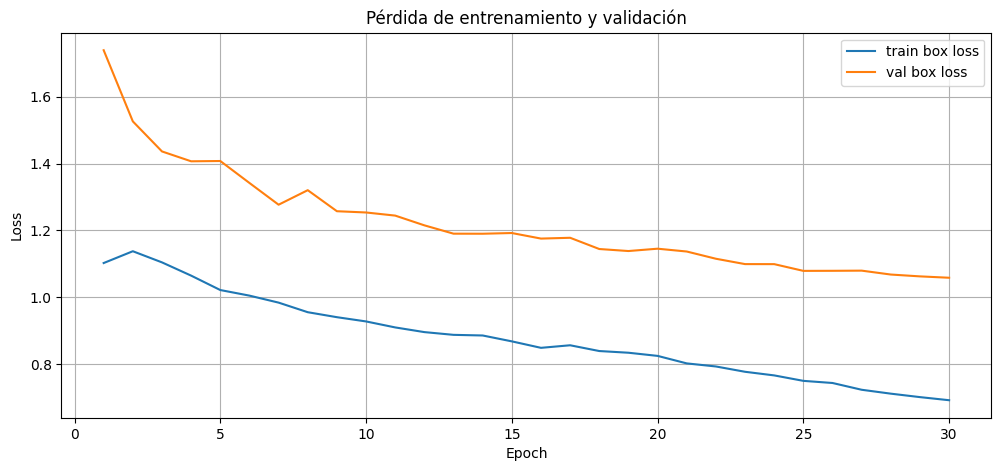

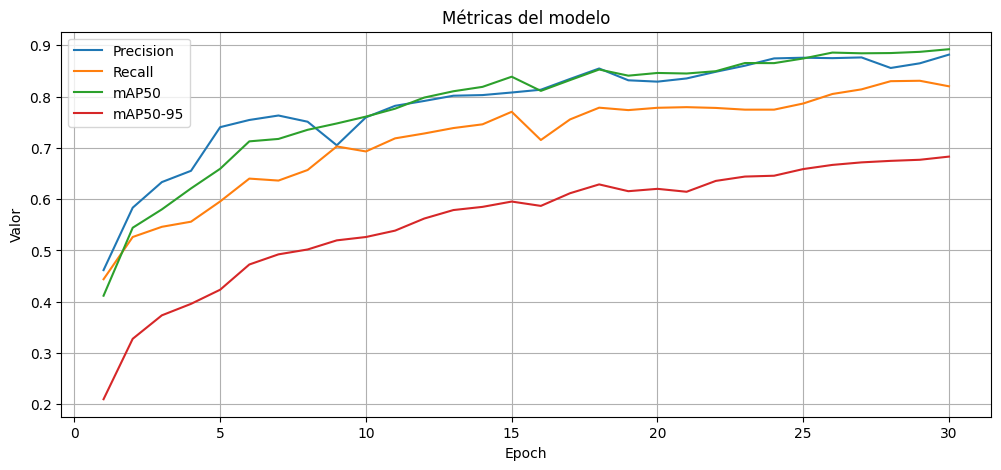

In [13]:
plt.figure(figsize=(12, 5))
plt.plot(df["epoch"], df["train/box_loss"], label="train box loss")
plt.plot(df["epoch"], df["val/box_loss"], label="val box loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Pérdida de entrenamiento y validación")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(df["epoch"], df["metrics/precision(B)"], label="Precision")
plt.plot(df["epoch"], df["metrics/recall(B)"], label="Recall")
plt.plot(df["epoch"], df["metrics/mAP50(B)"], label="mAP50")
plt.plot(df["epoch"], df["metrics/mAP50-95(B)"], label="mAP50-95")
plt.xlabel("Epoch")
plt.ylabel("Valor")
plt.title("Métricas del modelo")
plt.legend()
plt.grid(True)
plt.show()


In [14]:
test_images = list((DATASET_DIR / "test" / "images").glob("*.*"))
sample_test_image = test_images[0]

print("Imagen de prueba:", sample_test_image)

pred = best_model.predict(
    source=str(sample_test_image),
    conf=0.25,
    save=True,
    project=str(RUNS_DIR),
    name="predict_test_image",
    exist_ok=True
)


Imagen de prueba: c:\Users\jujob\OneDrive\Escritorio\Maestria\Segundo_Semestre\Vision Computacional\Proyecto_2\repo\proyecto_yolo_residuos\data\residuos_dataset\test\images\002ba7cf-R_3775_jpg.rf.EZ7mVdoSKtNROIwWtkrg.jpg

image 1/1 c:\Users\jujob\OneDrive\Escritorio\Maestria\Segundo_Semestre\Vision Computacional\Proyecto_2\repo\proyecto_yolo_residuos\data\residuos_dataset\test\images\002ba7cf-R_3775_jpg.rf.EZ7mVdoSKtNROIwWtkrg.jpg: 640x640 1 Paper, 77.2ms
Speed: 6.8ms preprocess, 77.2ms inference, 4.3ms postprocess per image at shape (1, 3, 640, 640)
Results saved to C:\Users\jujob\OneDrive\Escritorio\Maestria\Segundo_Semestre\Vision Computacional\Proyecto_2\repo\proyecto_yolo_residuos\runs\predict_test_image


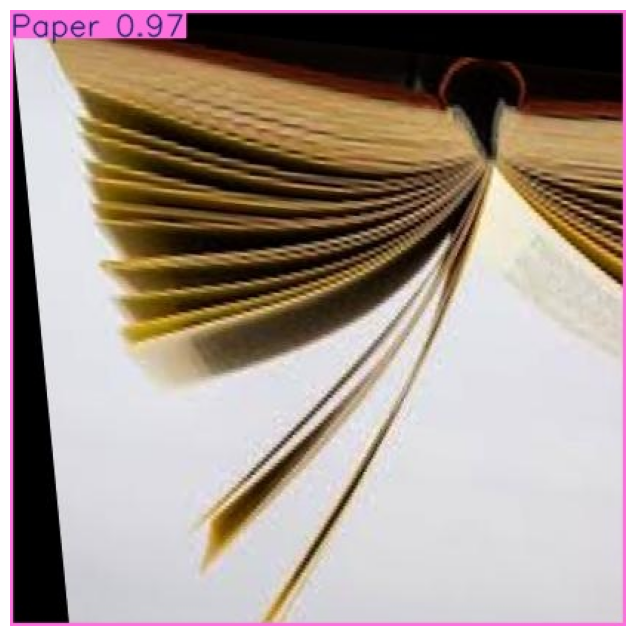

In [15]:
predicted_img_path = RUNS_DIR / "predict_test_image" / sample_test_image.name
img = Image.open(predicted_img_path)

plt.figure(figsize=(10, 8))
plt.imshow(img)
plt.axis("off")
plt.show()


In [16]:
predictions = best_model.predict(source=str(sample_test_image), conf=0.25)
class_names = best_model.names

for pred in predictions:
    for box, conf, cls in zip(pred.boxes.xyxy, pred.boxes.conf, pred.boxes.cls):
        print(
            "Clase:", class_names[int(cls.item())],
            "| Confianza:", round(conf.item(), 4),
            "| Box:", [round(x, 2) for x in box.tolist()]
        )



image 1/1 c:\Users\jujob\OneDrive\Escritorio\Maestria\Segundo_Semestre\Vision Computacional\Proyecto_2\repo\proyecto_yolo_residuos\data\residuos_dataset\test\images\002ba7cf-R_3775_jpg.rf.EZ7mVdoSKtNROIwWtkrg.jpg: 640x640 1 Paper, 77.0ms
Speed: 4.9ms preprocess, 77.0ms inference, 1.9ms postprocess per image at shape (1, 3, 640, 640)
Clase: Paper | Confianza: 0.9687 | Box: [0.0, 0.97, 415.91, 415.98]


In [17]:
video_path = PROJECT_ROOT / "test_video_2.mp4"

if video_path.exists():
    best_model.predict(
        source=str(video_path),
        conf=0.25,
        save=True,
        project=str(RUNS_DIR),
        name="predict_video",
        exist_ok=True
    )
    print("Video procesado.")
else:
    print("No existe test_video_2.mp4 en la raíz del proyecto.")



WARNING 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

video 1/1 (frame 1/231) c:\Users\jujob\OneDrive\Escritorio\Maestria\Segundo_Semestre\Vision Computacional\Proyecto_2\repo\proyecto_yolo_residuos\test_video_2.mp4: 640x384 1 Organic, 97.3ms
video 1/1 (frame 2/231) c:\Users\jujob\OneDrive\Escritorio\Maestria\Segundo_Semestre\Vision Computacional\Proyecto_2\repo\proyecto_yolo_residuos\test_video_2.mp4: 640x384 1 Organic, 46.6ms
video 1/1 (frame 3/231) c:\Users\jujob\OneDrive\Escritorio\Maestria\Segundo_Semestr

In [18]:
# Ejecutar esta celda solo para probar con camara
best_model.predict(source=0, show=True, conf=0.25)



1/1: 0... Success  (inf frames of shape 640x480 at 30.00 FPS)

WARNING 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

0: 480x640 (no detections), 1464.7ms
0: 480x640 (no detections), 13.1ms
0: 480x640 (no detections), 12.4ms
0: 480x640 (no detections), 12.4ms
0: 480x640 (no detections), 11.7ms
0: 480x640 (no detections), 11.5ms
0: 480x640 (no detections), 11.3ms
0: 480x640 (no detections), 11.4ms
0: 480x640 (no detections), 11.9ms
0: 480x640 (no detections), 12.2ms
0: 480x640 (no detections), 11.5ms
0: 480x640 

KeyboardInterrupt: 